# Business Case: LoanTap Logistic Regression

### Problem Statement:

Given a set of attributes for an Individual, determine if a credit line should be extended to them. If so, what should the repayment terms be in business recommendations?

### Data dictionary:

1. loan_amnt : The listed amount of the loan applied for by the borrower. If at some point in time, the credit department reduces the loan amount, then it will be reflected in this value.
2. term : The number of payments on the loan. Values are in months and can be either 36 or 60.
3. int_rate : Interest Rate on the loan
4. installment : The monthly payment owed by the borrower if the loan originates.
5. grade : LoanTap assigned loan grade
6. sub_grade : LoanTap assigned loan subgrade
7. emp_title :The job title supplied by the Borrower when applying for the loan.*
8. emp_length : Employment length in years. Possible values are between 0 and 10 where 0 means less than one year and 10 means ten or more years.
9. home_ownership : The home ownership status provided by the borrower during registration or obtained from the credit report.
10. annual_inc : The self-reported annual income provided by the borrower during registration.
11. verification_status : Indicates if income was verified by LoanTap, not verified, or if the income source was verified
12. issue_d : The month which the loan was funded
13. loan_status : Current status of the loan - Target Variable
14. purpose : A category provided by the borrower for the loan request.
15. title : The loan title provided by the borrower
16. dti : A ratio calculated using the borrower’s total monthly debt payments on the total debt obligations, excluding mortgage and the requested LoanTap loan, divided by the 2. borrower’s self-reported monthly income.
17. earliest_cr_line :The month the borrower's earliest reported credit line was opened
18. open_acc : The number of open credit lines in the borrower's credit file.
19. pub_rec : Number of derogatory public records
20. revol_bal : Total credit revolving balance
21. revol_util : Revolving line utilization rate, or the amount of credit the borrower is using relative to all available revolving credit.
22. total_acc : The total number of credit lines currently in the borrower's credit file
23. initial_list_status : The initial listing status of the loan. Possible values are – W, F
24. application_type : Indicates whether the loan is an individual application or a joint application with two co-borrowers
25. mort_acc : Number of mortgage accounts.
26. pub_rec_bankruptcies : Number of public record bankruptcies
27. Address: Address of the individual

In [1]:
# Import the necessary libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import statsmodels.api as sm
from sklearn.feature_selection import VarianceThreshold
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.metrics import precision_recall_curve, average_precision_score

In [2]:
# Importing the data

df = pd.read_csv(r"D:\Scaler\10 Intro to ML and NN\Business Case Study\02 Business Case LoanTap Logistic Regression\logistic_regression.csv")

In [3]:
data = df.copy()

In [4]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


# 1. Define Problem Statement and perform Exploratory Data Analysis 
- Definition of problem (as per given problem statement with additional views)
- Observations on shape of data, data types of all the attributes, conversion of categorical attributes to 'category' (If required), missing value detection, statistical summary.
- Univariate Analysis (distribution plots of all the continuous variable(s) barplots/countplots of all the categorical variables)
- Bivariate Analysis (Relationships between important variable)
- Illustrate the insights based on EDA
    - Comments on range of attributes, outliers of various attributes
    - Comments on the distribution of the variables and relationship between them
    - Comments for each univariate and bivariate plots

In [5]:
print("Shape of the data :", df.shape)

Shape of the data : (396030, 27)


In [6]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,...,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,application_type,mort_acc,pub_rec_bankruptcies,address
0,10000.0,36 months,11.44,329.48,B,B4,Marketing,10+ years,RENT,117000.0,...,16.0,0.0,36369.0,41.8,25.0,w,INDIVIDUAL,0.0,0.0,"0174 Michelle Gateway\r\nMendozaberg, OK 22690"
1,8000.0,36 months,11.99,265.68,B,B5,Credit analyst,4 years,MORTGAGE,65000.0,...,17.0,0.0,20131.0,53.3,27.0,f,INDIVIDUAL,3.0,0.0,"1076 Carney Fort Apt. 347\r\nLoganmouth, SD 05113"
2,15600.0,36 months,10.49,506.97,B,B3,Statistician,< 1 year,RENT,43057.0,...,13.0,0.0,11987.0,92.2,26.0,f,INDIVIDUAL,0.0,0.0,"87025 Mark Dale Apt. 269\r\nNew Sabrina, WV 05113"
3,7200.0,36 months,6.49,220.65,A,A2,Client Advocate,6 years,RENT,54000.0,...,6.0,0.0,5472.0,21.5,13.0,f,INDIVIDUAL,0.0,0.0,"823 Reid Ford\r\nDelacruzside, MA 00813"
4,24375.0,60 months,17.27,609.33,C,C5,Destiny Management Inc.,9 years,MORTGAGE,55000.0,...,13.0,0.0,24584.0,69.8,43.0,f,INDIVIDUAL,1.0,0.0,"679 Luna Roads\r\nGreggshire, VA 11650"


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 396030 entries, 0 to 396029
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   loan_amnt             396030 non-null  float64
 1   term                  396030 non-null  object 
 2   int_rate              396030 non-null  float64
 3   installment           396030 non-null  float64
 4   grade                 396030 non-null  object 
 5   sub_grade             396030 non-null  object 
 6   emp_title             373103 non-null  object 
 7   emp_length            377729 non-null  object 
 8   home_ownership        396030 non-null  object 
 9   annual_inc            396030 non-null  float64
 10  verification_status   396030 non-null  object 
 11  issue_d               396030 non-null  object 
 12  loan_status           396030 non-null  object 
 13  purpose               396030 non-null  object 
 14  title                 394274 non-null  object 
 15  

In [8]:
print("Data types of all columns:\n")
print(df.dtypes)

Data types of all columns:

loan_amnt               float64
term                     object
int_rate                float64
installment             float64
grade                    object
sub_grade                object
emp_title                object
emp_length               object
home_ownership           object
annual_inc              float64
verification_status      object
issue_d                  object
loan_status              object
purpose                  object
title                    object
dti                     float64
earliest_cr_line         object
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
initial_list_status      object
application_type         object
mort_acc                float64
pub_rec_bankruptcies    float64
address                  object
dtype: object


In [9]:
# Identify object-type columns (possible categorical variables)

object_cols = df.select_dtypes(include='object').columns
print("Object columns:\n", object_cols)

# Optionally convert to 'category' type

for col in object_cols:
    df[col] = df[col].astype('category')

print("\nUpdated data types:\n")
print(df.dtypes)

Object columns:
 Index(['term', 'grade', 'sub_grade', 'emp_title', 'emp_length',
       'home_ownership', 'verification_status', 'issue_d', 'loan_status',
       'purpose', 'title', 'earliest_cr_line', 'initial_list_status',
       'application_type', 'address'],
      dtype='object')

Updated data types:

loan_amnt                float64
term                    category
int_rate                 float64
installment              float64
grade                   category
sub_grade               category
emp_title               category
emp_length              category
home_ownership          category
annual_inc               float64
verification_status     category
issue_d                 category
loan_status             category
purpose                 category
title                   category
dti                      float64
earliest_cr_line        category
open_acc                 float64
pub_rec                  float64
revol_bal                float64
revol_util               float64

In [10]:
# Check for missing values

missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

mort_acc                37795
emp_title               22927
emp_length              18301
title                    1756
pub_rec_bankruptcies      535
revol_util                276
dtype: int64


In [11]:
# Summary statistics for numerical columns

print("Summary statistics for numerical attributes:\n")
df.describe()

Summary statistics for numerical attributes:



,loan_amnt,int_rate,installment,annual_inc,dti,open_acc,pub_rec,revol_bal,revol_util,total_acc,mort_acc,pub_rec_bankruptcies
count,396030.000000,396030.000000,396030.000000,3.960300e+05,396030.000000,396030.000000,396030.000000,3.960300e+05,395754.000000,396030.000000,358235.000000,395495.000000
mean,14113.888089,13.639400,431.849698,7.420318e+04,17.379514,11.311153,0.178191,1.584454e+04,53.791749,25.414744,1.813991,0.121648
std,8357.441341,4.472157,250.727790,6.163762e+04,18.019092,5.137649,0.530671,2.059184e+04,24.452193,11.886991,2.147930,0.356174
min,500.000000,5.320000,16.080000,0.000000e+00,0.000000,0.000000,0.000000,0.000000e+00,0.000000,2.000000,0.000000,0.000000
25%,8000.000000,10.490000,250.330000,4.500000e+04,11.280000,8.000000,0.000000,6.025000e+03,35.800000,17.000000,0.000000,0.000000
50%,12000.000000,13.330000,375.430000,6.400000e+04,16.910000,10.000000,0.000000,1.118100e+04,54.800000,24.000000,1.000000,0.000000
75%,20000.000000,16.490000,567.300000,9.000000e+04,22.980000,14.000000,0.000000,1.962000e+04,72.900000,32.000000,3.000000,0.000000
max,40000.000000,30.990000,1533.810000,8.706582e+06,9999.000000,90.000000,86.000000,1.743266e+06,892.300000,151.000000,34.000000,8.000000


In [12]:
# Summary statistics for categorical columns

print("\nSummary for categorical attributes:\n")
df.describe(include='category')


Summary for categorical attributes:



,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,purpose,title,earliest_cr_line,initial_list_status,application_type,address
count,396030,396030,396030,373103,377729,396030,396030,396030,396030,396030,394274,396030,396030,396030,396030
unique,2,7,35,173105,11,6,3,115,2,14,48816,684,2,3,393700
top,36 months,B,B3,Teacher,10+ years,MORTGAGE,Verified,Oct-2014,Fully Paid,debt_consolidation,Debt consolidation,Oct-2000,f,INDIVIDUAL,USS Smith\r\nFPO AP 70466
freq,302005,116018,26655,4389,126041,198348,139563,14846,318357,234507,152472,3017,238066,395319,8


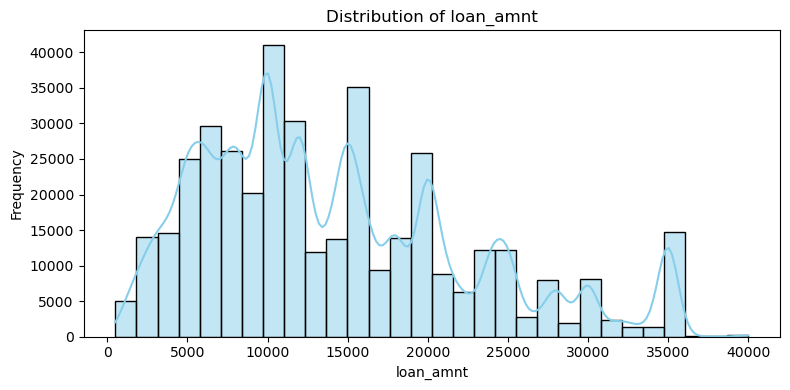

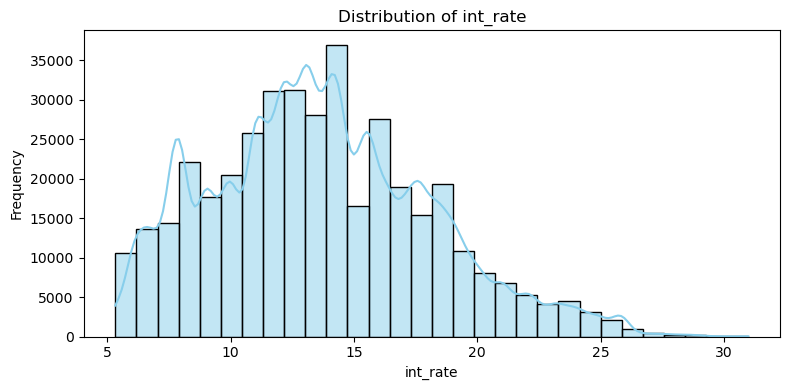

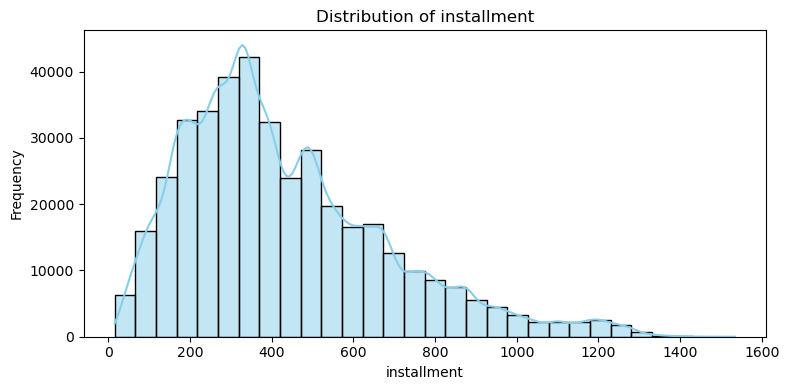

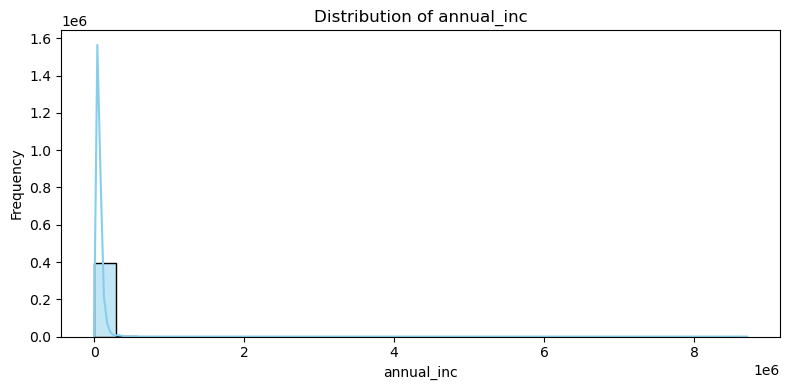

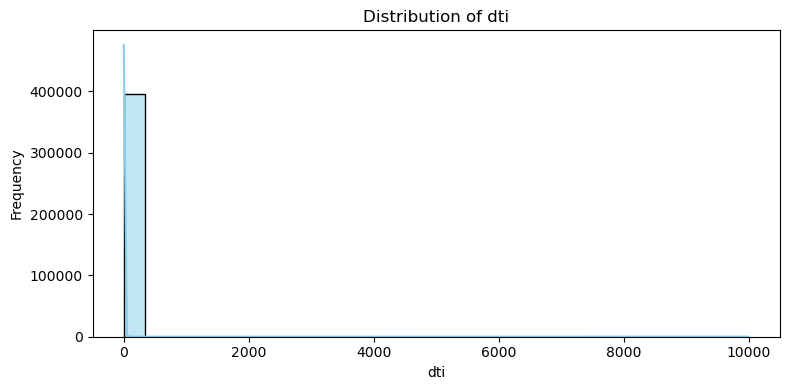

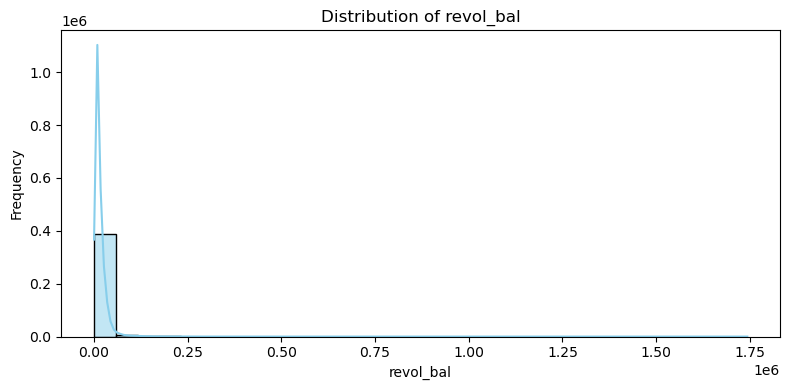

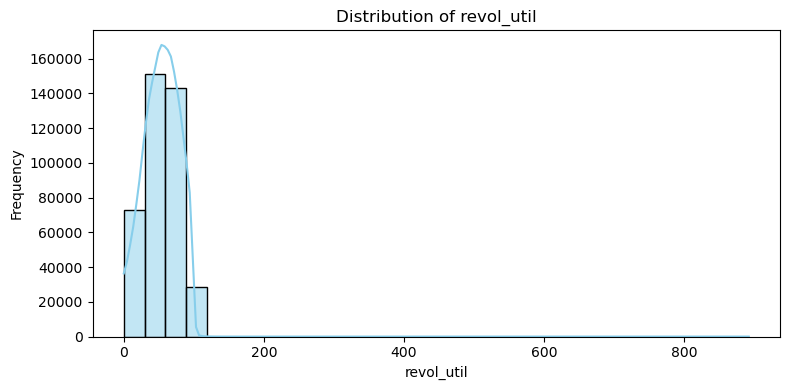

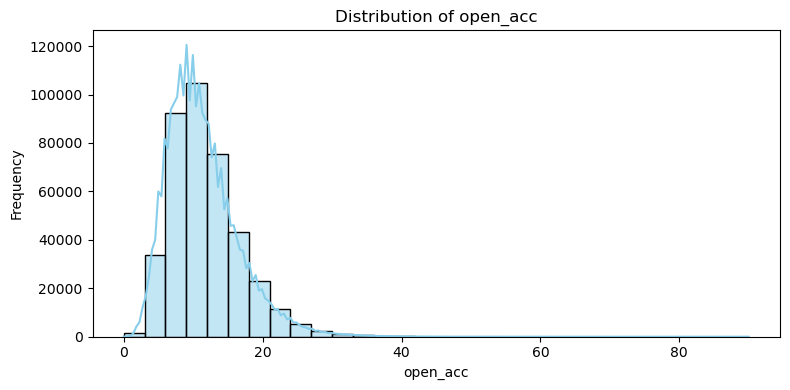

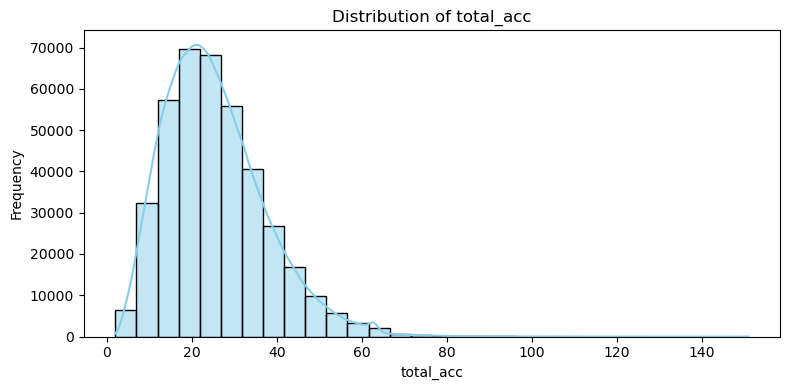

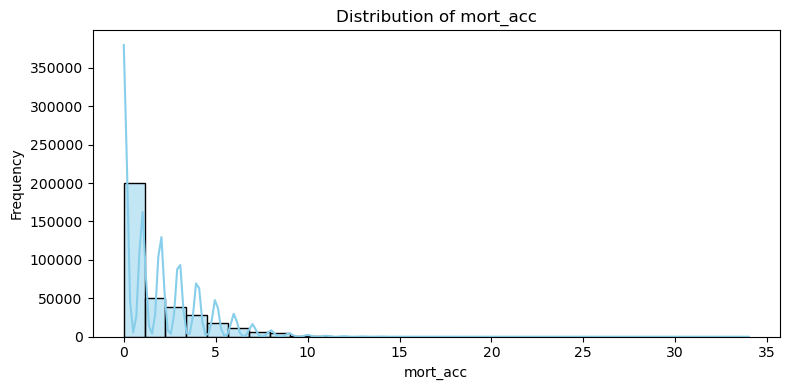

In [13]:
# Univariate analysis for Numerical columns

numerical_cols = ['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'revol_bal', 'revol_util', 'open_acc', 'total_acc', 'mort_acc']

for col in numerical_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), kde=True, bins=30, color='skyblue')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

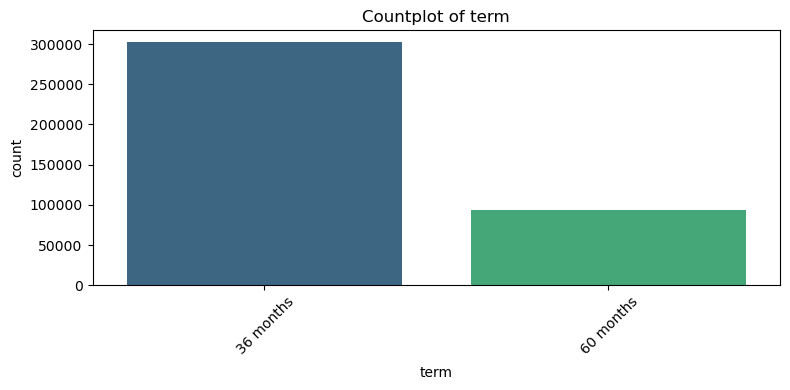

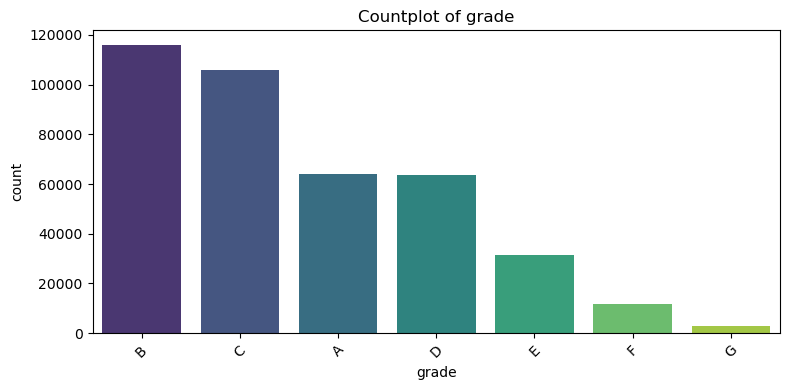

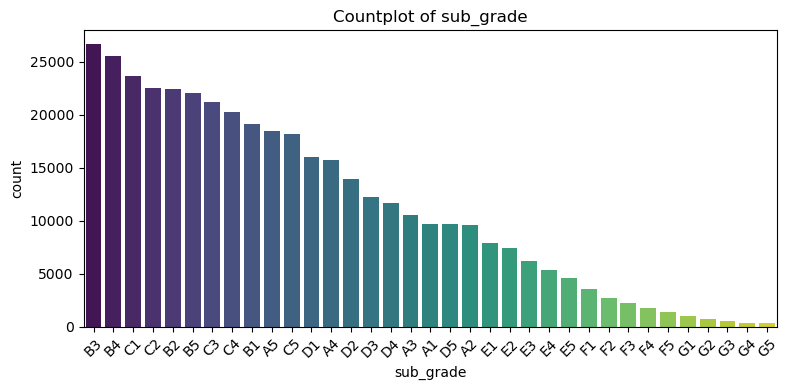

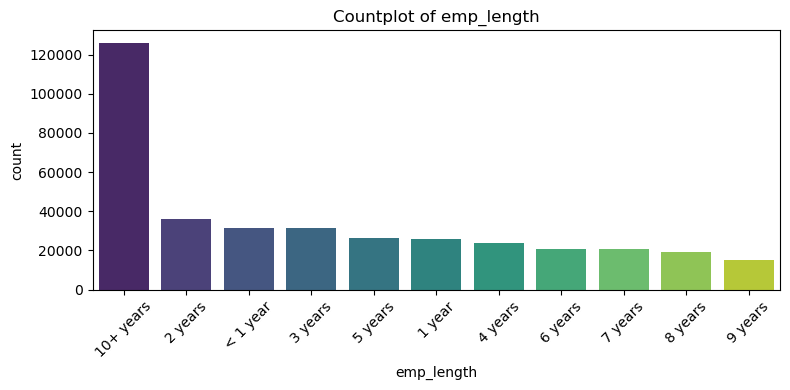

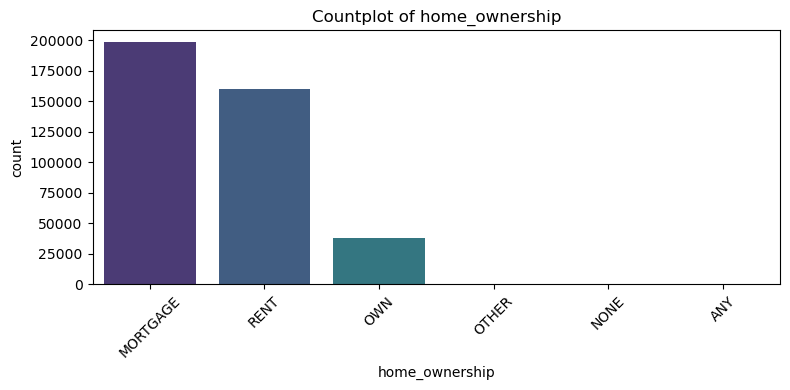

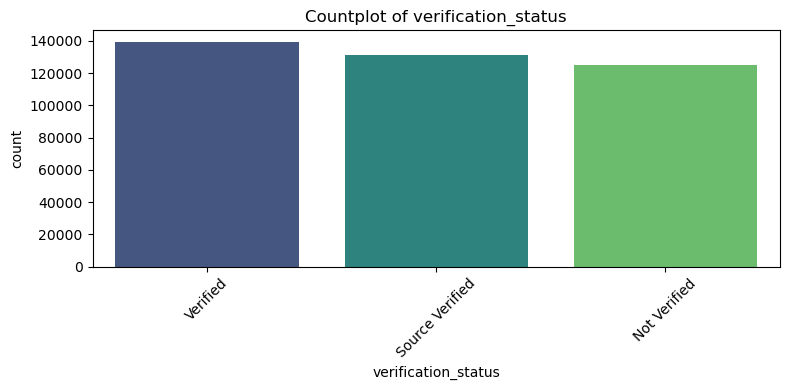

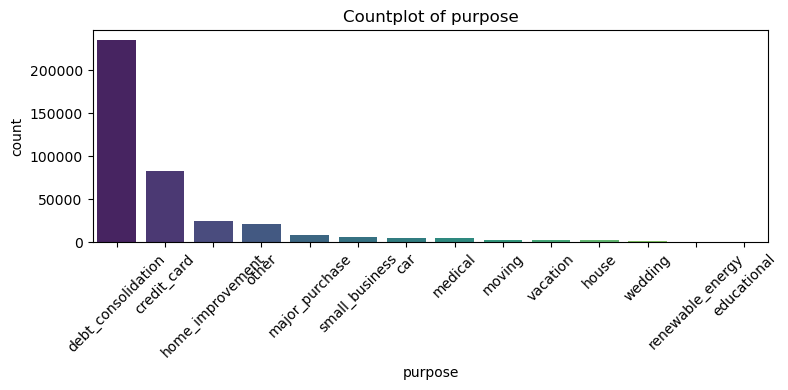

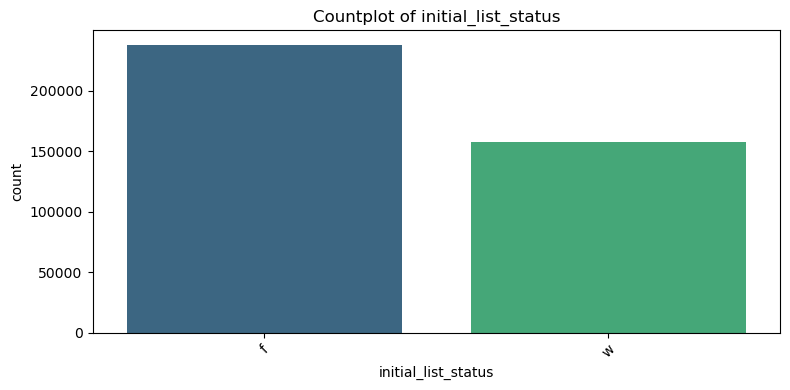

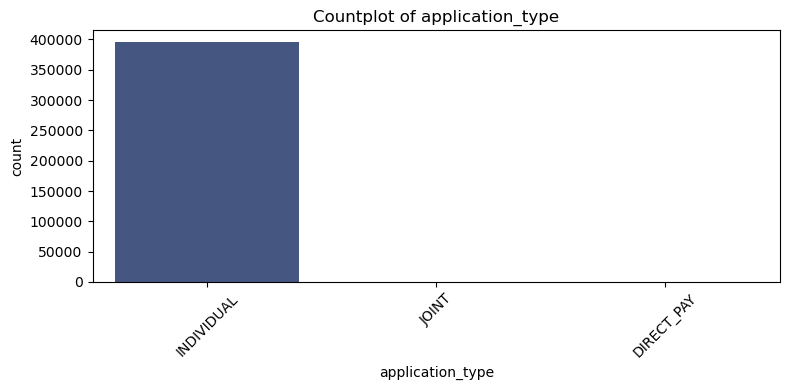

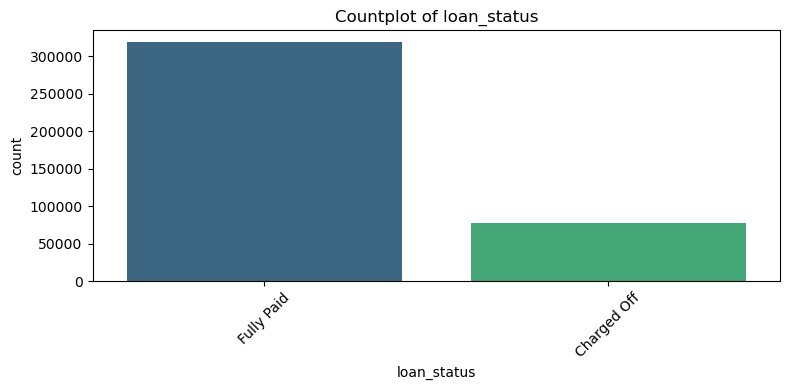

In [14]:
# Univariate analysis for Catogery columns

categorical_cols = ['term', 'grade', 'sub_grade', 'emp_length', 'home_ownership', 'verification_status', 'purpose', 'initial_list_status', 'application_type', 'loan_status']

# Plot countplots
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, data=df, palette='viridis', order=df[col].value_counts().index)
    plt.title(f'Countplot of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

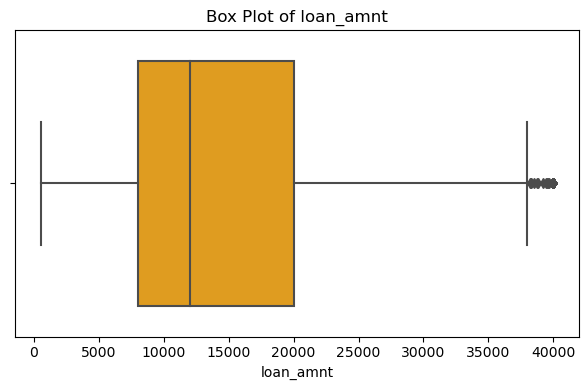

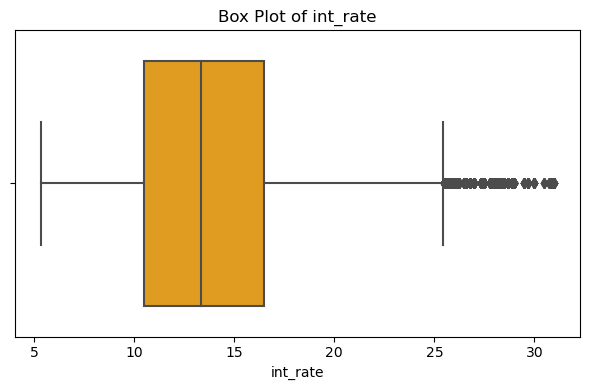

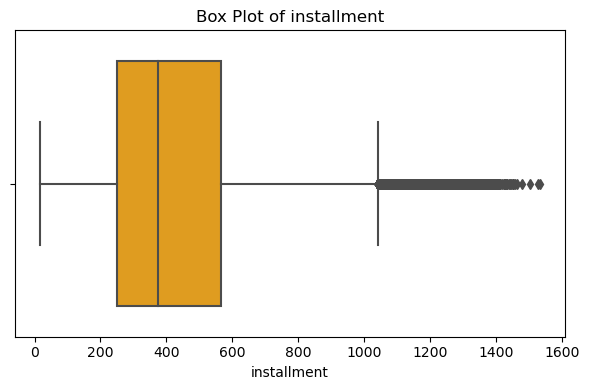

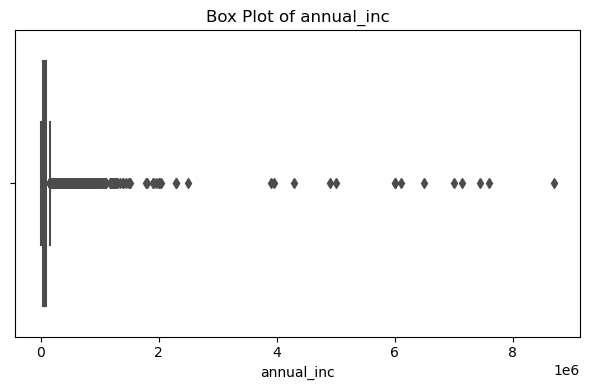

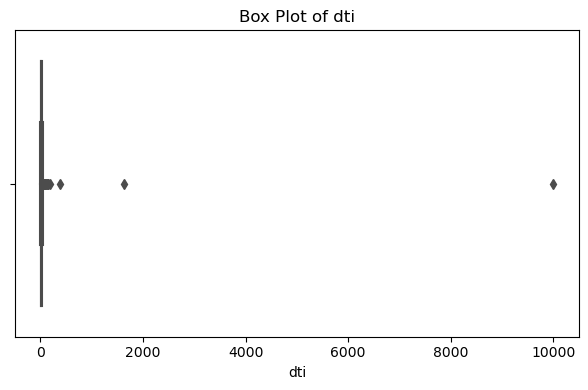

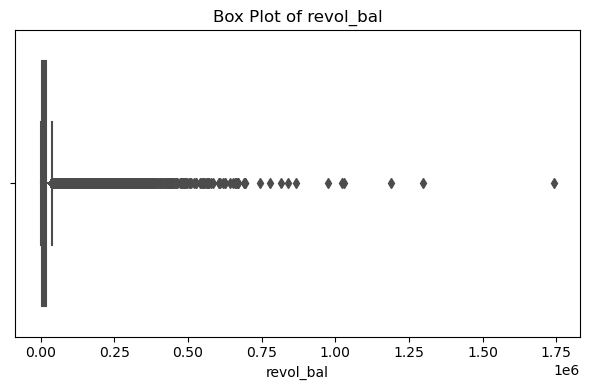

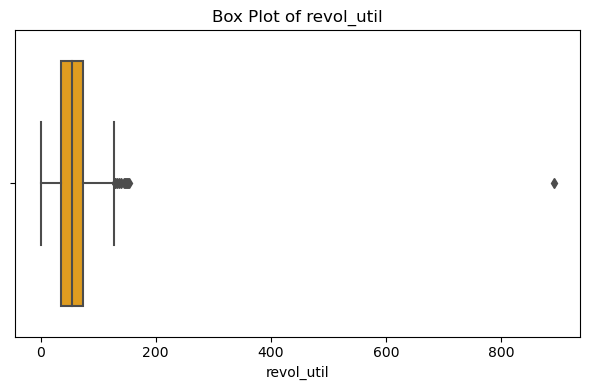

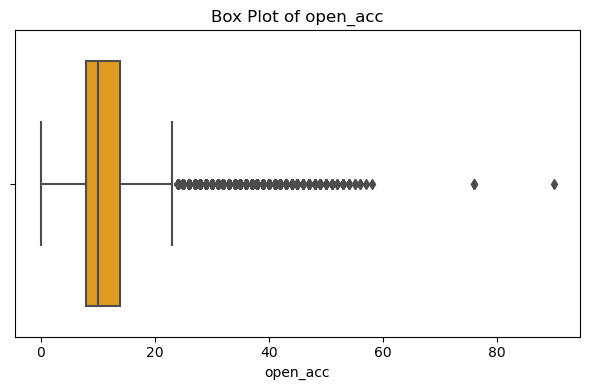

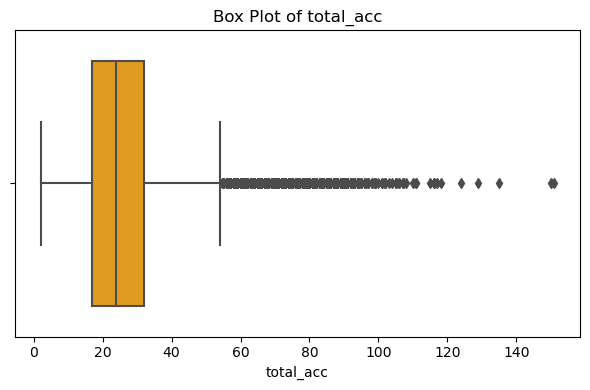

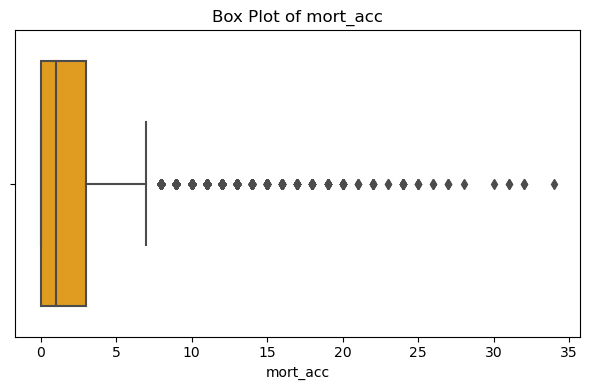

In [15]:
# Boxplots for each numerical variable

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[col], color='orange')
    plt.title(f'Box Plot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

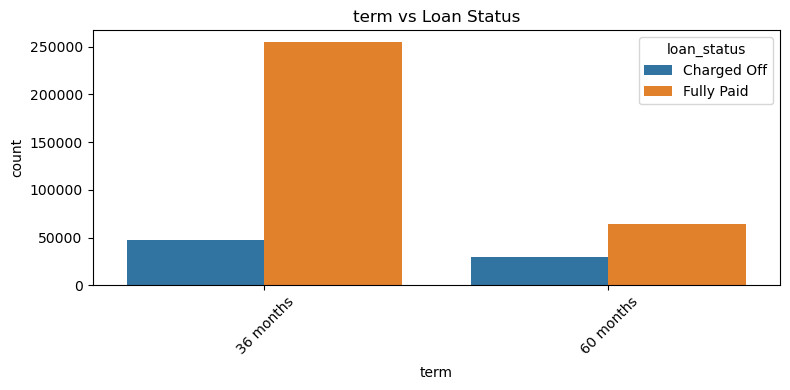

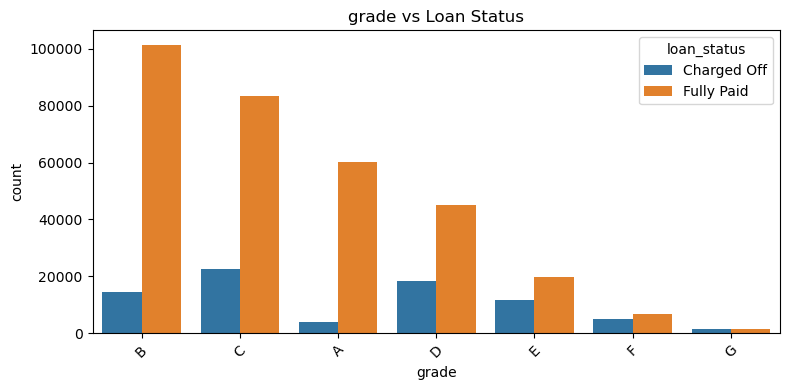

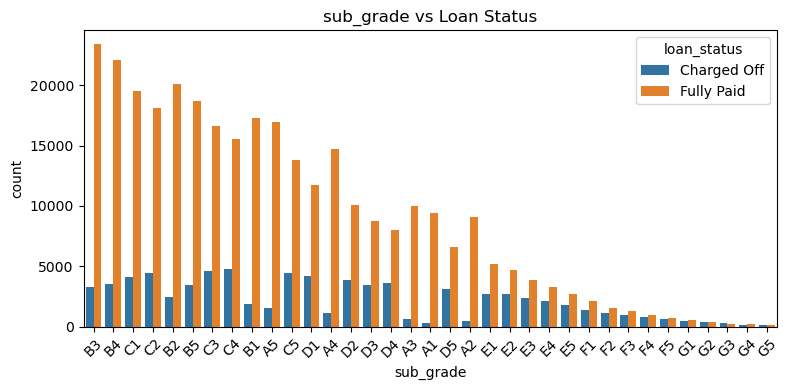

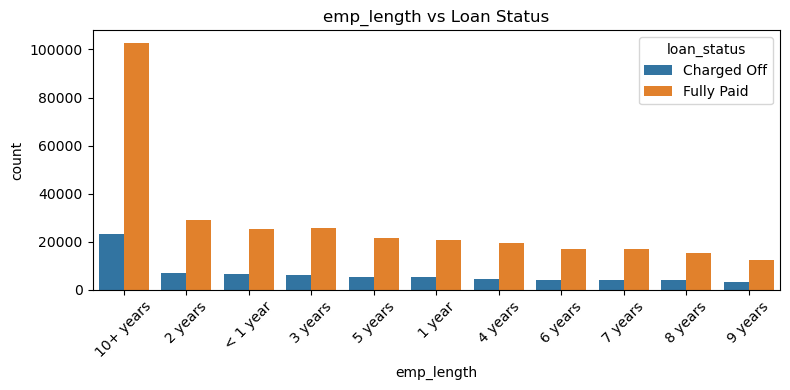

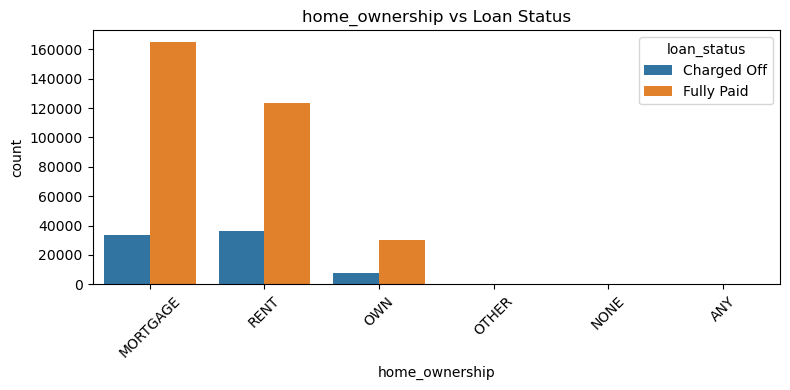

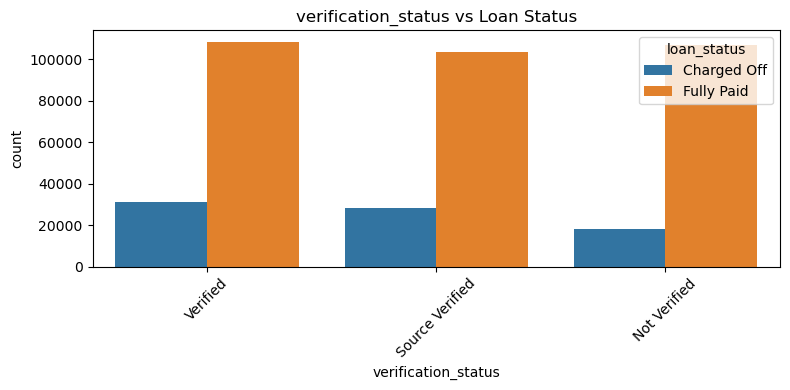

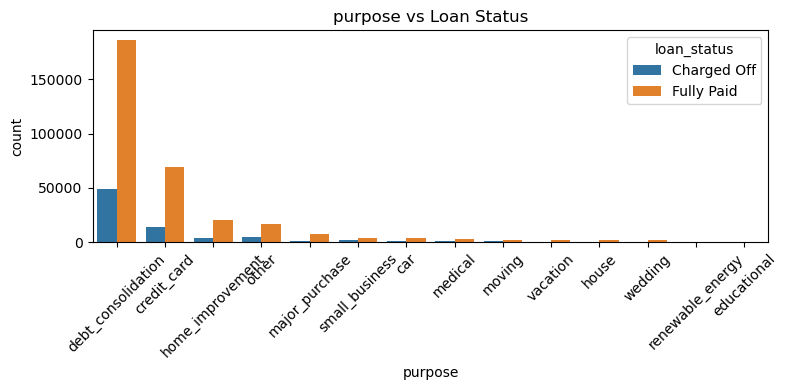

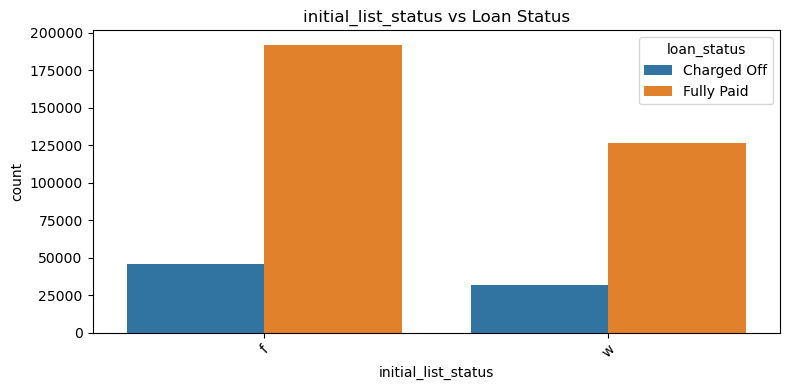

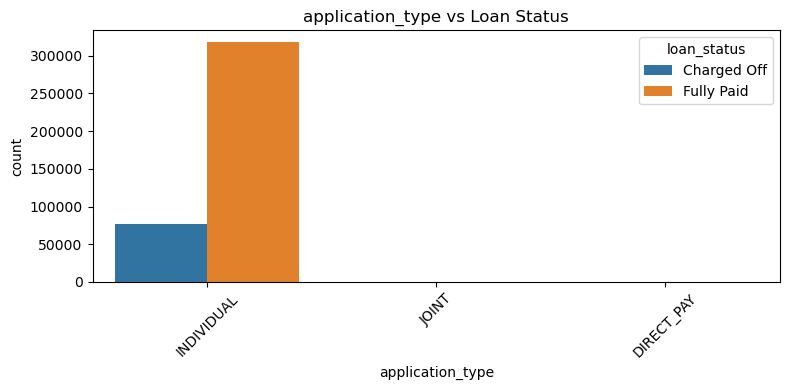

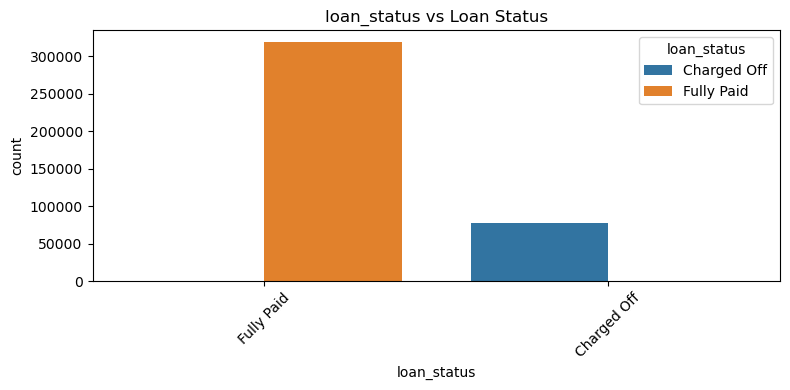

In [16]:
# Bivariate analysis for Categorical vs target - Countplot

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(x=col, hue='loan_status', data=df, order=df[col].value_counts().index)
    plt.title(f'{col} vs Loan Status')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

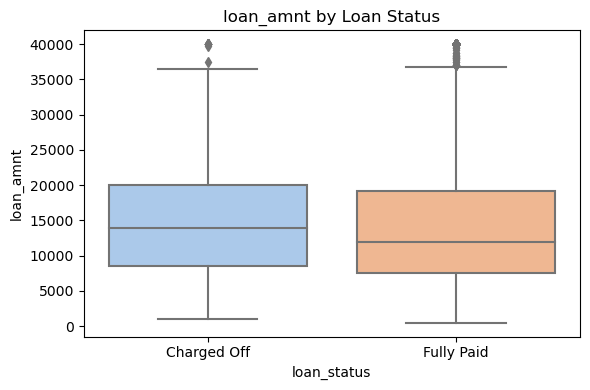

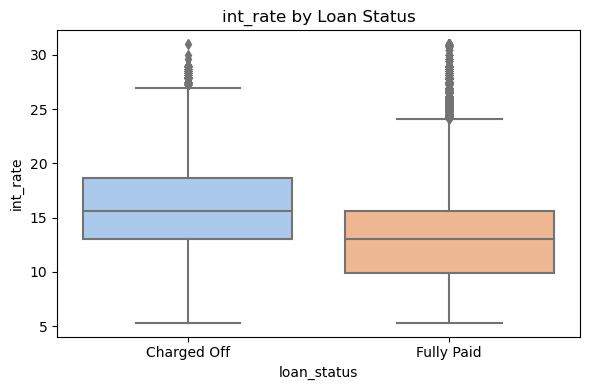

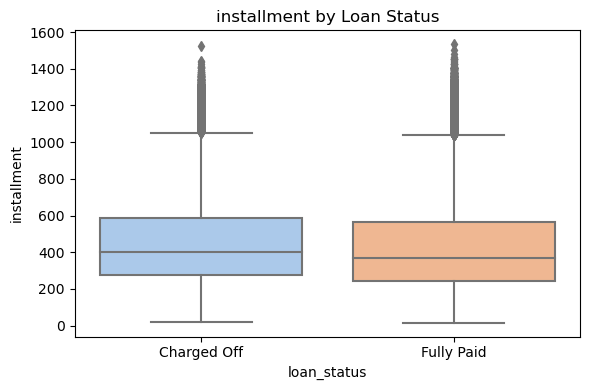

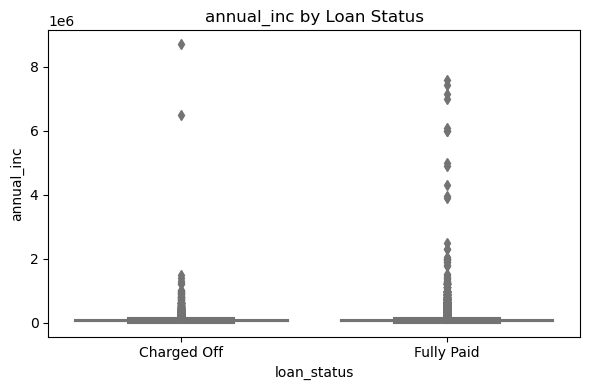

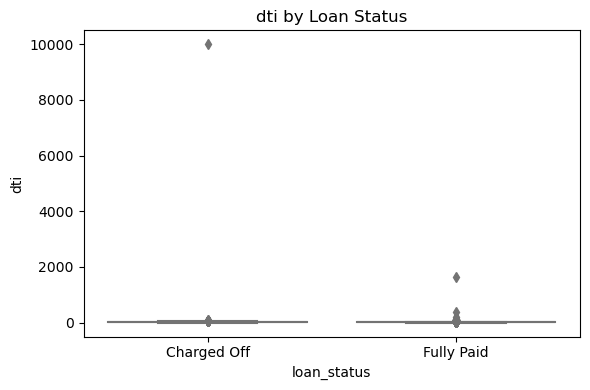

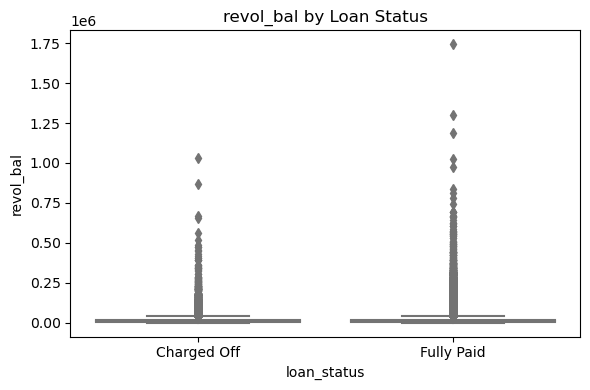

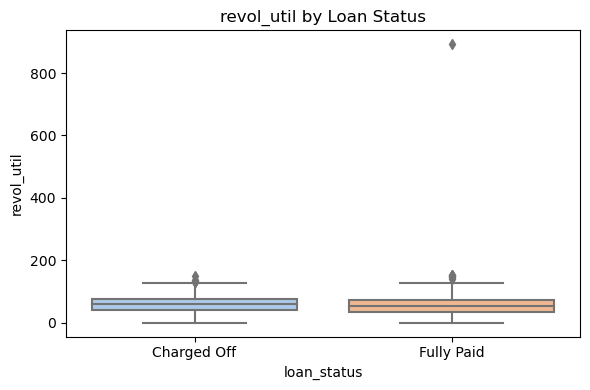

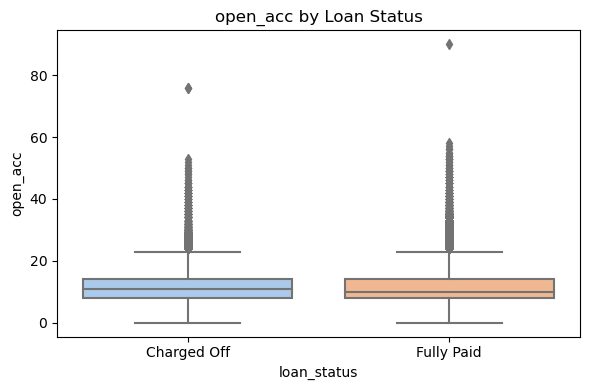

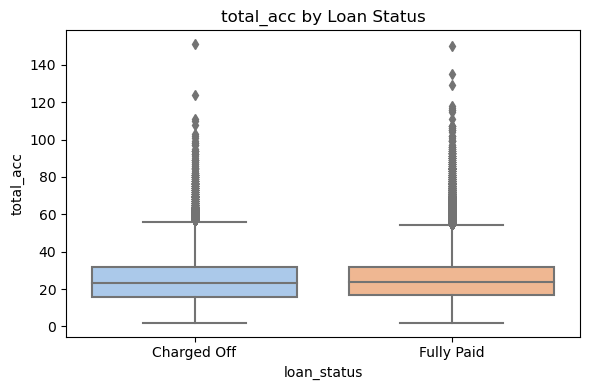

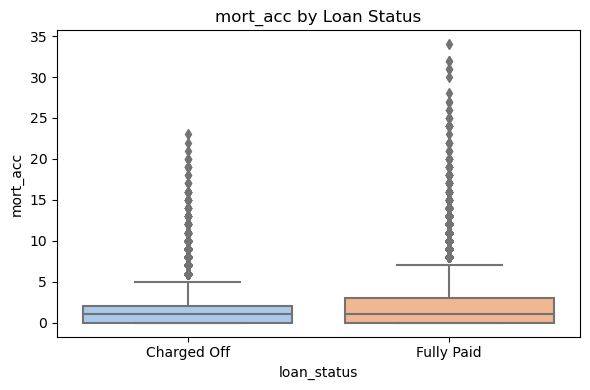

In [17]:
# Bivariate analysis for Continuous vs target - Boxplot

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(x='loan_status', y=col, data=df, palette='pastel')
    plt.title(f'{col} by Loan Status')
    plt.tight_layout()
    plt.show()

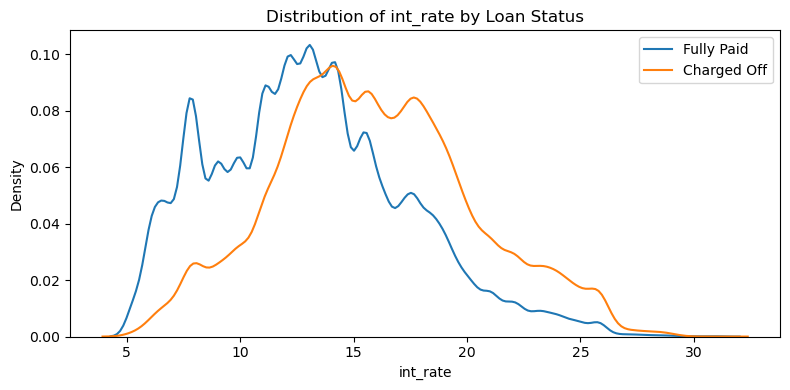

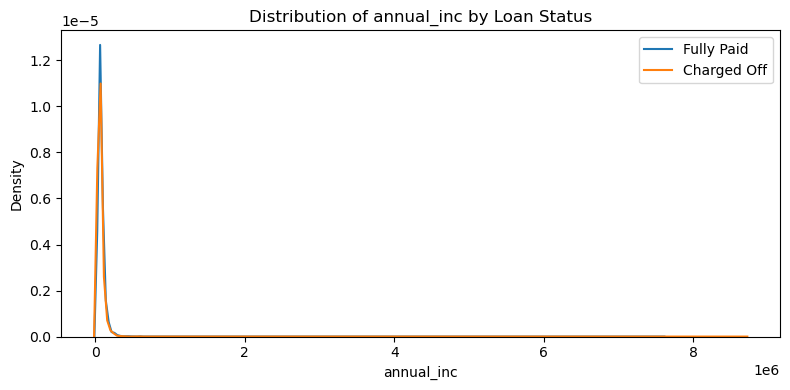

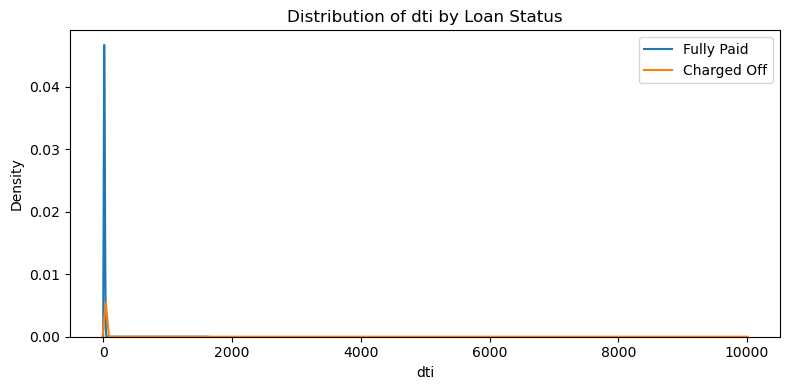

In [18]:
# KDE plots - Distribution Overlap

for col in ['int_rate', 'annual_inc', 'dti']:
    plt.figure(figsize=(8, 4))
    for status in df['loan_status'].unique():
        sns.kdeplot(df[df['loan_status'] == status][col], label=status)
    plt.title(f'Distribution of {col} by Loan Status')
    plt.legend()
    plt.tight_layout()
    plt.show()

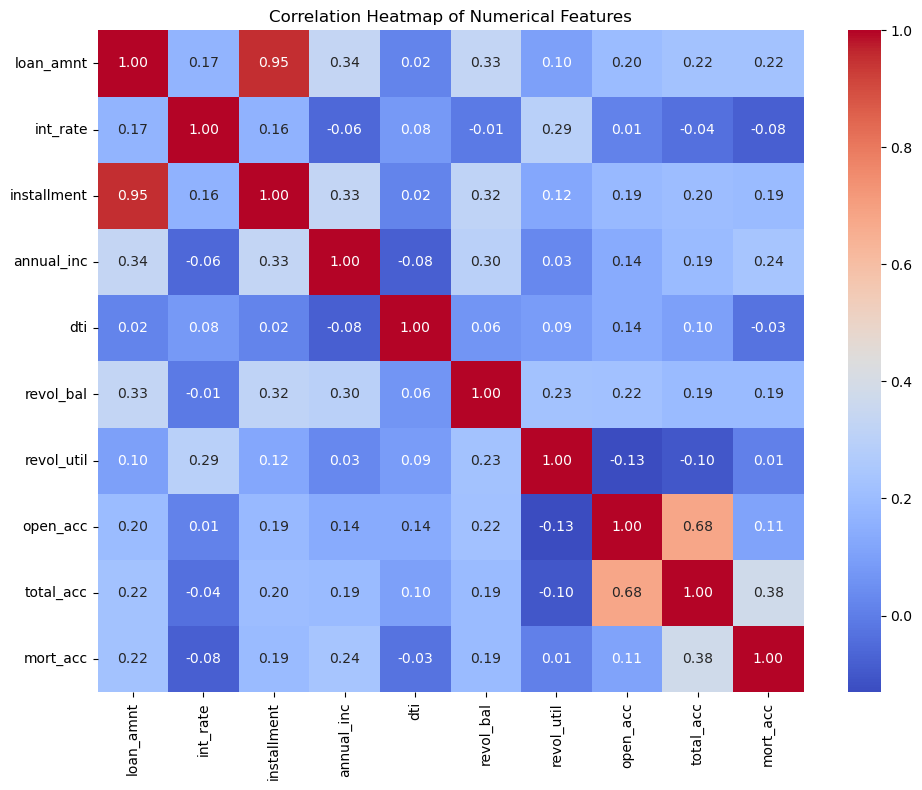

In [19]:
# Correlation Matrix

plt.figure(figsize=(10, 8))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()

### Comments on range of attributes, outliers of various attributes

1. Distribution of Continuous Variables

- loan_amnt:
    - Ranges from ₹500 to ₹40,000.
    - Most loan requests fall between ₹5,000 to ₹20,000.
    - Distribution is slightly right-skewed, with a few high-value outliers.

- int_rate:
    - Varies from approximately 5% to 30%.
    - Applicants with higher interest rates tend to show higher loan risk.
    - Charged-off loans are more common at higher interest rates.

- installment:
    - Monthly installments vary based on loan amount and interest rate.
    - Distributions reflect a similar skew to loan_amnt.

- annual_inc:
    - Wide range from ₹10,000 to over ₹10,000,000 (₹1 Cr).
    - Majority fall between ₹2L to ₹10L.
    - Strong right-skew with significant outliers — high incomes may be unreliable or need capping.

- dti (Debt-to-Income Ratio):
    - Mostly lies between 5% and 25%.
    - Some applicants have DTI > 40%, which may indicate high credit stress.
    - Outliers exist and could signal risk-prone individuals.

- revol_bal (Revolving Balance):
    - Varies from ₹0 to ₹1,000,000+.
    - Most users have balances below ₹50,000.
    - Outliers suggest high credit card dependency.

- revol_util (Revolving Utilization):
    - Typically between 0% and 90%.
    - High revol_util indicates applicants are utilizing most of their credit, a potential red flag.
    - Outliers near or above 100% exist.

- open_acc & total_acc:
    - Number of credit accounts ranges from 0 to over 60.
    - Most borrowers have 5–20 credit accounts.
    - Very high values may indicate high credit exposure.

2. Categorical Variables & Their Influence

- term:
    - Two categories: 36 and 60 months.
    - 60-month loans show slightly higher default rates in bivariate analysis.

- grade & sub_grade:
    - Grade levels from A to G; sub_grades further divide these.
    - Higher grades (A–C) are more likely to be fully paid.
    - Subgrades D5 and below show a spike in charge-offs.

- emp_length:
    - Ranges from 0 (less than 1 year) to 10+ years.
    - Applicants with 5+ years of experience show better repayment behavior.

- home_ownership:
    - Categories include RENT, OWN, MORTGAGE.
    - OWN and MORTGAGE show slightly better repayment than RENT.

- verification_status:
    - Verified income applicants show better loan status.
    - Loans issued without income verification are riskier.

- purpose:
    - Most common: debt_consolidation, credit_card, home_improvement.
    - Small business and medical purposes have relatively higher default rates.

- application_type:
    - Individual applications dominate.
    - Joint applications are fewer but may represent lower risk.

- loan_status (Target Variable):
    - Includes classes like “Fully Paid”, “Charged Off”.
    - Skewed toward Fully Paid; model handling must consider imbalance.

### Comments on the distribution of the variables and relationship between them

1. Distribution of Variables (Univariate Trends)

- Loan Amount (loan_amnt)
    - Positively skewed. Most applicants request loans under ₹20,000.
    - A few applicants request amounts over ₹35,000, indicating outliers.

- Interest Rate (int_rate)
    - Slight right skew. Concentrated between 10% and 20%.
    - Higher rates are associated with subprime grades.

- Annual Income (annual_inc)
    - Highly right-skewed. Most applicants report income between ₹2L to ₹10L.
    - Presence of outliers (> ₹50L) possibly due to incorrect or inflated reporting.

- Debt-to-Income Ratio (dti)
    - Bell-shaped distribution with a peak around 15%.
    - Some outliers with DTI > 40% raise flags about loan affordability.

- Revolving Utilization (revol_util)
    - Skewed toward higher values. Many applicants are using 60–90% of available revolving credit.
    - Very high utilization may correlate with financial stress.

- Credit History (open_acc, total_acc)
    - Most borrowers have 5–20 accounts.
    - Skewed right with a few applicants holding very high numbers of accounts.

2. Relationship Between Variables (Bivariate Trends)

- Loan Status vs Grade/Subgrade:
    - Clear pattern: lower grades (E, F, G) have higher charge-off rates.
    - Higher subgrades like A1–B5 show better repayment outcomes.

- Interest Rate vs Grade:
    - Strong inverse relationship — lower grades receive higher interest rates.

- Annual Income vs Loan Status:
    - Applicants with higher income tend to have more loans marked "Fully Paid".
    - However, extremely high incomes don't always guarantee repayment.

- Revol Util vs Loan Status:
    - High credit utilization strongly correlates with higher charge-off rates.

- Emp Length vs Loan Status:
    - Borrowers with longer employment (5+ years) are more likely to repay loans successfully.

- Purpose vs Loan Status:
    - Debt consolidation and credit card refinancing dominate the dataset.
    - Purposes like small business or medical expenses are more associated with defaults.

- Verification Status vs Loan Status:
    - Verified income correlates with better repayment behavior.
    - Non-verified applicants show higher risk.

### Comments for each univariate and bivariate plots

1. Univariate Plot

- Loan Amount (loan_amnt) – Histogram/Boxplot
    - Most loans range between ₹5,000 and ₹20,000. A few high-value loan requests are outliers. Distribution is right-skewed, indicating most borrowers request smaller loans.

-  Interest Rate (int_rate) – Histogram/Boxplot
    - Concentrated between 10% to 20%. Higher interest rates are offered to riskier profiles. Outliers exist with rates exceeding 25%.

- Annual Income (annual_inc) – Histogram/Boxplot
    - Highly skewed with extreme outliers beyond ₹50L. Most applicants report income under ₹10L, with a long tail of inflated/self-reported high incomes.

- Debt-to-Income Ratio (dti) – Histogram/Boxplot
    - Most values fall below 25%, with some individuals showing extremely high DTI values — signaling over-leveraged applicants.

- Revolving Balance (revol_bal) – Histogram/Boxplot
    - Majority hold revolving balances under ₹50,000. Some users have balances over ₹1L, suggesting high dependency on credit lines.

- Revolving Utilization (revol_util) – Histogram/Boxplot
    - Distribution is heavily concentrated between 20–80%. A considerable number of applicants are near 100%, raising credit stress concerns.

- Employment Length (emp_length) – Countplot
    - Most borrowers have 10+ years or 1 year of experience. Consistent employment is common, but some show no experience.

- Loan Purpose (purpose) – Countplot
    - Debt consolidation and credit card refinancing dominate. Medical and small business loans are less common.

- Grade / Subgrade – Countplot
    - Grade B and C are most common. Lower grades (F, G) are less frequent and typically associated with higher default risk.

2. Bivariate Analysis: Plot-wise Comments

- Loan Status vs Grade
    - Default rates rise steadily from Grade A to G. Grade A has the highest "Fully Paid" ratio, while Grade F/G see more "Charged Off" cases.

- Loan Status vs Term
    - 60-month loans have a slightly higher proportion of defaults compared to 36-month loans, suggesting longer commitments increase risk.

- Loan Status vs Employment Length
    - Borrowers with more than 5 years of experience show better repayment behavior. Shorter tenures correlate with higher charge-offs.

- Loan Status vs Home Ownership
    - Homeowners and those with mortgages show slightly better repayment patterns than renters, possibly indicating financial stability.

- Loan Status vs Verification Status
    - Verified income borrowers show a significantly lower default rate. Lack of income verification is associated with higher risk.

- Loan Status vs Purpose
    - Small business and medical loans show relatively high default rates. In contrast, debt consolidation and credit card loans are common and more balanced in terms of loan status.

- Boxplot: Annual Income vs Loan Status
    - Median income for "Fully Paid" loans is slightly higher. However, outliers in both groups suggest income alone isn't a definitive factor.

- Boxplot: Interest Rate vs Loan Status
    - "Charged Off" loans have significantly higher interest rates on average, confirming interest rate is used as a risk differentiator.

- Boxplot: Revolving Utilization vs Loan Status
    - Defaulters tend to have higher credit utilization, indicating credit overuse might be a warning sign.

# 2. Data Preprocessing
- Duplicate value check
- Missing value treatment
- Outlier treatment
- Feature engineering
- Data preparation for modeling

In [20]:
# Check for duplicate rows in the dataset

duplicate_rows = df[df.duplicated()]

print(f"Number of duplicate rows: {duplicate_rows.shape[0]}")

Number of duplicate rows: 0


In [21]:
# Checking Missing values

missing_values = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100


missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage (%)': missing_percent})
missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values(by='Percentage (%)', ascending=False)
display(missing_df)

,Missing Values,Percentage (%)
mort_acc,37795,9.543469
emp_title,22927,5.789208
emp_length,18301,4.621115
title,1756,0.443401
pub_rec_bankruptcies,535,0.135091
revol_util,276,0.069692


In [22]:
# Fill numerical columns with median

num_cols = df.select_dtypes(include=['float64', 'int64']).columns
for col in num_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

In [23]:
# Fill categorical columns with mode

cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].mode()[0], inplace=True)

In [24]:
# Checking the missing values after the updates

print("Missing values after treatment:")
print(df.isnull().sum().sum())

Missing values after treatment:
0


In [25]:
df['emp_length'].unique()

['10+ years', '4 years', '< 1 year', '6 years', '9 years', ..., '3 years', '8 years', '7 years', '5 years', '1 year']
Length: 11
Categories (11, object): ['1 year', '10+ years', '2 years', '3 years', ..., '7 years', '8 years', '9 years', '< 1 year']

In [26]:
# Outlier Detection and Treatment using IQR method

num_cols = df.select_dtypes(include=['float64', 'int64']).columns

def treat_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    print(f"\nColumn: {column}")
    print(f"Lower Bound: {lower_bound}, Upper Bound: {upper_bound}")
    print(f"Number of outliers: {df[(df[column] < lower_bound) | (df[column] > upper_bound)].shape[0]}")
    
    
    df[column] = np.where(df[column] > upper_bound, upper_bound,
                          np.where(df[column] < lower_bound, lower_bound, df[column]))


for col in num_cols:
    treat_outliers_iqr(df, col)


Column: loan_amnt
Lower Bound: -10000.0, Upper Bound: 38000.0
Number of outliers: 191

Column: int_rate
Lower Bound: 1.4900000000000038, Upper Bound: 25.489999999999995
Number of outliers: 3777

Column: installment
Lower Bound: -225.12499999999986, Upper Bound: 1042.7549999999999
Number of outliers: 11250

Column: annual_inc
Lower Bound: -22500.0, Upper Bound: 157500.0
Number of outliers: 16700

Column: dti
Lower Bound: -6.270000000000001, Upper Bound: 40.53
Number of outliers: 275

Column: open_acc
Lower Bound: -1.0, Upper Bound: 23.0
Number of outliers: 10307

Column: pub_rec
Lower Bound: 0.0, Upper Bound: 0.0
Number of outliers: 57758

Column: revol_bal
Lower Bound: -14367.5, Upper Bound: 40012.5
Number of outliers: 21259

Column: revol_util
Lower Bound: -19.600000000000016, Upper Bound: 128.40000000000003
Number of outliers: 12

Column: total_acc
Lower Bound: -5.5, Upper Bound: 54.5
Number of outliers: 8499

Column: mort_acc
Lower Bound: -4.5, Upper Bound: 7.5
Number of outliers: 

In [27]:
# Feature engineering


# Convert to datetime
df['issue_d'] = pd.to_datetime(df['issue_d'], errors='coerce')
df['earliest_cr_line'] = pd.to_datetime(df['earliest_cr_line'], errors='coerce')


# New features

df['issue_year'] = df['issue_d'].dt.year
df['credit_age'] = df['issue_d'].dt.year - df['earliest_cr_line'].dt.year


# Create income loan ratio

df['income_to_loan_ratio'] = df['annual_inc'] / df['loan_amnt']


# Create a Bin based on emp length

def emp_length_to_bin(emp_length):
    if 'year' in emp_length:
        # Extract the number of years
        if '< 1 year' in emp_length:
            return '<1yr'
        elif '10+ years' in emp_length:
            return '5-10yrs'
        else:
            years = int(emp_length.split()[0])
            if years < 1:
                return '<1yr'
            elif 1 <= years < 5:
                return '1-5yrs'
            elif 5 <= years < 10:
                return '5-10yrs'
            else:
                return '5-10yrs'
    return 'Unknown'


df['emp_length_bin'] = df['emp_length'].apply(emp_length_to_bin)


# Clean and convert emp_length

df['emp_length'] = df['emp_length'].str.replace('+', '', regex=False)
df['emp_length'] = df['emp_length'].str.replace('< 1', '0', regex=False)
df['emp_length'] = df['emp_length'].str.extract('(\d+)').astype(float)


# Strip text and convert to integer

df['term'] = df['term'].str.strip().str.replace(' months', '').astype(int)


# Combine rare purposes into 'Other'

top_purposes = df['purpose'].value_counts().nlargest(5).index
df['purpose_grouped'] = df['purpose'].apply(lambda x: x if x in top_purposes else 'Other')


# Flag for high revolving utilization

df['high_revol_util'] = df['revol_util'].apply(lambda x: 1 if x > 90 else 0)


# One-hot encode all categorical variables

label_enc_cols = ['grade', 'sub_grade', 'emp_length_bin']
label_encoders = {}

for col in label_enc_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

# One-hot encode nominal features

df = pd.get_dummies(df, columns=['home_ownership', 'verification_status', 'initial_list_status', 'application_type', 'purpose_grouped'], drop_first=True)

In [28]:
df.select_dtypes(include=['object', 'category']).columns

Index(['emp_title', 'issue_d', 'loan_status', 'purpose', 'title',
       'earliest_cr_line', 'address'],
      dtype='object')

In [29]:
df.head()

,loan_amnt,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,annual_inc,issue_d,...,verification_status_Source Verified,verification_status_Verified,initial_list_status_w,application_type_INDIVIDUAL,application_type_JOINT,purpose_grouped_credit_card,purpose_grouped_debt_consolidation,purpose_grouped_home_improvement,purpose_grouped_major_purchase,purpose_grouped_other
0,10000.0,36,11.44,329.48,1,8,Marketing,10.0,117000.0,2015-01-01,...,False,False,True,True,False,False,False,False,False,False
1,8000.0,36,11.99,265.68,1,9,Credit analyst,4.0,65000.0,2015-01-01,...,False,False,False,True,False,False,True,False,False,False
2,15600.0,36,10.49,506.97,1,7,Statistician,0.0,43057.0,2015-01-01,...,True,False,False,True,False,True,False,False,False,False
3,7200.0,36,6.49,220.65,0,1,Client Advocate,6.0,54000.0,2014-11-01,...,False,False,False,True,False,True,False,False,False,False
4,24375.0,60,17.27,609.33,2,14,Destiny Management Inc.,9.0,55000.0,2013-04-01,...,False,True,False,True,False,True,False,False,False,False


In [30]:
# Data preparation for modeling


# drop irrelavent columns
 
drop_cols = ['emp_title', 'title', 'address', 'issue_d', 'earliest_cr_line', 'purpose'] 
df.drop(columns=drop_cols, inplace=True)


# Encode target variable (loan_status) — assuming binary classification

df['loan_status'] = df['loan_status'].map({'Fully Paid': 0, 'Charged Off': 1})


# Define features and target

X = df.drop('loan_status', axis=1)
y = df['loan_status']

# Split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Apply scaling

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3. Model building
- Build the Logistic Regression model and comment on the model statistics
- Display model coefficients with column names

In [31]:
# Logistics Regression Model

model = LogisticRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.81      0.98      0.89     63629
           1       0.52      0.08      0.15     15577

    accuracy                           0.80     79206
   macro avg       0.67      0.53      0.52     79206
weighted avg       0.76      0.80      0.74     79206



In [32]:
# Model coefficients

coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_[0]
})


coefficients = coefficients.sort_values(by='Coefficient', key=abs, ascending=False)

print(coefficients)

                                Feature  Coefficient
5                             sub_grade     0.693371
2                              int_rate    -0.208048
8                                   dti     0.177823
0                             loan_amnt     0.159081
7                            annual_inc    -0.147765
9                              open_acc     0.134334
12                           revol_util     0.130717
1                                  term     0.127548
18                 income_to_loan_ratio    -0.120291
3                           installment    -0.114494
13                            total_acc    -0.102325
11                            revol_bal    -0.087765
16                           issue_year     0.084123
31          purpose_grouped_credit_card    -0.079328
26  verification_status_Source Verified     0.074372
32   purpose_grouped_debt_consolidation    -0.072629
25                  home_ownership_RENT     0.062920
27         verification_status_Verified     0.

# 4. Results Evaluation 
- ROC AUC Curve & comments
- Precision Recall Curve & comments
- Classification Report (Confusion Matrix etc)
- Tradeoff Questions:
    - How can we make sure that our model can detect real defaulters and there are less false positives? This is important as we can lose out on an opportunity to finance more individuals and earn interest on it.
    - Since NPA (non-performing asset) is a real problem in this industry, it’s important we play safe and shouldn’t disburse loans to anyone.

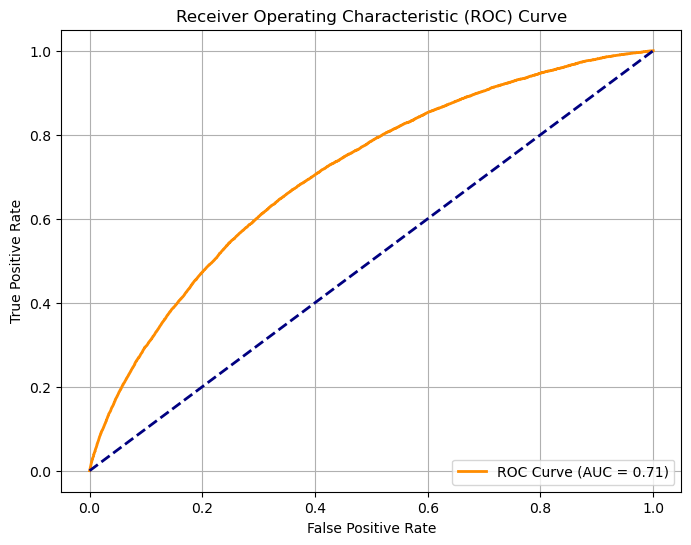

In [33]:
# Predict probabilities for the positive class

y_probs = model.predict_proba(X_test_scaled)[:, 1]

# Compute ROC curve and ROC AUC score

fpr, tpr, thresholds = roc_curve(y_test, y_probs)
roc_auc = roc_auc_score(y_test, y_probs)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid()
plt.show()

#### Comments on ROC AUC Curve

- AUC Score: 0.71
    - An AUC of 0.71 indicates moderate discriminative power of the model.
    - This means the model is able to correctly distinguish between the positive and negative classes (e.g., defaulters vs non-defaulters) 71% of the time.

- Interpretation of the Curve Shape:
    - The ROC curve rises above the diagonal (baseline), suggesting the model performs better than random guessing.
    - However, there's still room for improvement as the curve isn’t very steep or close to the top-left corner, which would indicate a highly accurate model.

- Model Performance:
    - While this model shows reasonable classification ability, additional steps like feature selection, removal of noise, balancing the classes, or even trying other models (e.g., Random Forest, XGBoost) could enhance performance.

- Business Implication:
    - In a loan underwriting context, a 0.71 AUC implies the model can provide useful guidance for risk-based decision-making, though critical or high-value applications might need more robust performance.



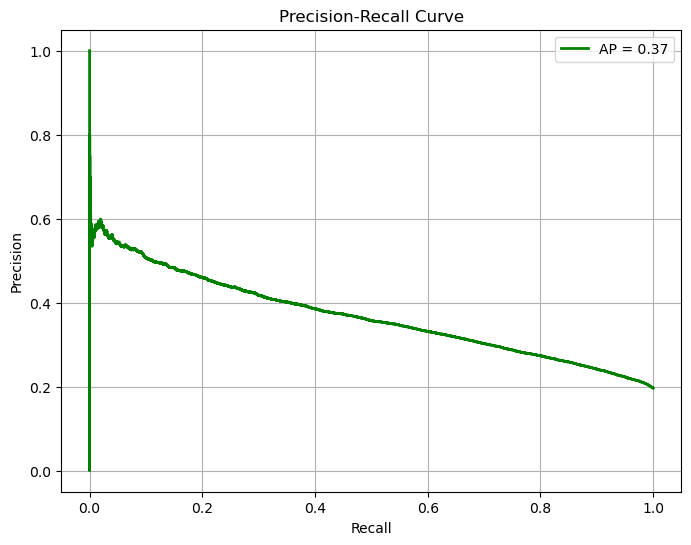

In [34]:
# Get predicted probabilities for the positive class

y_scores = model.predict_proba(X_test_scaled)[:, 1]

# Calculate precision and recall

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)
avg_precision = average_precision_score(y_test, y_scores)


plt.figure(figsize=(8, 6))
plt.plot(recall, precision, color='green', lw=2, label=f'AP = {avg_precision:.2f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid()
plt.show()

#### Precision-Recall Curve Evaluation Comments
1. Average Precision Score (AP = 0.37)
    - An AP of 0.37 suggests the model has limited ability to distinguish between the positive and negative classes.
    - This is lower than ideal, especially in imbalanced classification problems like loan default prediction.

2. Curve Shape Interpretation
    - The curve drops rapidly from a high precision at very low recall values.
    - This indicates that the model can identify a few positives with high precision, but performance drops significantly as it tries to identify more positives (higher recall).
    - The precision stabilizes in the 0.2 to 0.5 range for most recall values, which isn’t optimal.

3. What It Tells About Your Model
    - Your model may be producing many false positives or missing a lot of actual positive cases (i.e., defaults), depending on the threshold.
    - It's less reliable in high-stakes decision-making unless further refined.

4. Business Implication
    - For a credit risk model, this means:
    - It may be good for catching a few clear defaulters.
    - But not yet robust enough to generalize well across the broader loan applicant population.
    - You might end up either rejecting too many good applicants or approving risky ones.

5. Recommendations
    - Try improving the model by:
    - Balancing the dataset (e.g., using SMOTE or undersampling).
    - Feature engineering or selection (e.g., removing multicollinearity).
    - Testing other classifiers like Random Forest, XGBoost, etc.
    - Threshold tuning for better F1/Precision-Recall tradeoff.

In [35]:
# Classification report

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion matrix

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)


Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.98      0.89     63629
           1       0.52      0.08      0.15     15577

    accuracy                           0.80     79206
   macro avg       0.67      0.53      0.52     79206
weighted avg       0.76      0.80      0.74     79206


Confusion Matrix:
[[62423  1206]
 [14256  1321]]


#### Tradeoff Discussion & Results Evaluation
1. How can we make sure that our model can detect real defaulters and there are fewer false positives? This is important as we can lose out on an opportunity to finance more individuals and earn interest on it.

- To ensure the model reliably identifies true defaulters while minimizing false positives (i.e., not wrongly rejecting trustworthy borrowers), the following strategies can be applied:

- Adjusting the Classification Threshold:
    - By default, predictions above 0.5 are considered defaulters. However, increasing the threshold (e.g., to 0.6 or 0.7) can help reduce false positives, thereby allowing more good borrowers to be approved for loans.

- Optimize Using a Cost-Sensitive Approach:
    - A custom evaluation framework that considers the cost of false negatives (approving a defaulter) and the cost of false positives (rejecting a good customer) should be applied. This ensures the model's decision-making aligns with business profitability.

- Precision-Recall Tradeoff:
    - By analyzing the precision-recall curve, we can find an optimal point where the model maintains high precision (reducing false positives) without sacrificing recall (catching most defaulters).

- Advanced Modeling & Feature Engineering:
    - Using advanced algorithms like Random Forest or XGBoost and creating insightful features (e.g., loan-to-income ratio, credit utilization) can enhance the model's discriminative power, improving prediction accuracy.

- Monitoring & Recalibration:
    - Models must be monitored and retrained periodically to stay effective as borrower behaviors and market dynamics evolve.

2. Since NPA (Non-Performing Asset) is a real problem in this industry, it’s important we play safe and shouldn’t disburse loans to anyone.

- While being conservative with loan disbursement may seem like a safe strategy to prevent NPAs, being overly restrictive can significantly hurt business growth and revenue potential. Here's a balanced approach:

- Risk-Based Segmentation:
    - Instead of outright rejecting borrowers, segment them into risk buckets (e.g., low, medium, high risk). Medium- or high-risk customers can be offered stricter terms (e.g., lower loan amounts, higher interest rates, shorter tenure).

- Smart Threshold Tuning:
    - We can reduce false negatives (i.e., avoid giving loans to defaulters) by lowering the classification threshold. This increases recall and prioritizes safety over aggressive lending.

- Reject Informedly, Not Blindly:
    - The goal is not to reject everyone, but to reject those with the highest default risk based on statistically sound predictions. Blanket rejections might prevent NPAs but also lose potential interest revenue from worthy borrowers.

- Blending Business and Risk Objectives:
    - A careful trade-off between risk mitigation and business growth should be established. A well-calibrated model helps the organization make profitable yet safe lending decisions, rather than rejecting all applications.



Around 80.39 % of customers have fully paid their loans, as seen from the loan_status distribution


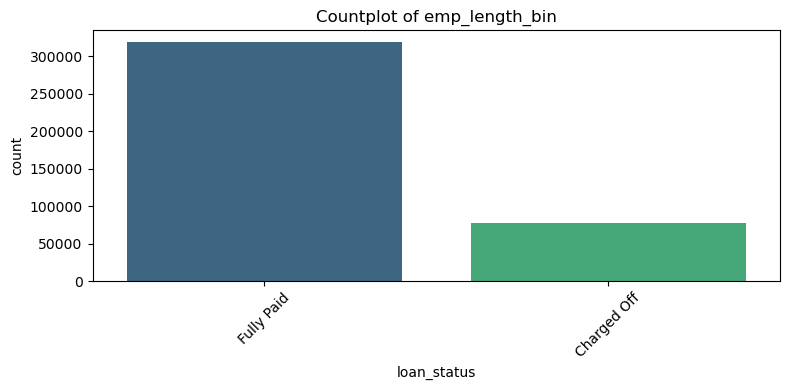

In [36]:
# What percentage of customers have fully paid their Loan Amount

print('Around',round((data[data['loan_status']=='Fully Paid'].shape[0] / data.shape[0]) * 100,2), '% of customers have fully paid their loans, as seen from the loan_status distribution')

plt.figure(figsize=(8, 4))
sns.countplot(x=data['loan_status'], palette='viridis')
plt.title(f'Countplot of {col}')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [37]:
# Comment about the correlation between Loan Amount and Installment features.

correlation = data['loan_amnt'].corr(data['installment'])

print(correlation)

print('There is a strong positive correlation between Loan Amount and Installment. As expected, higher loan amounts tend to result in higher monthly installments.')

0.9539289082616207
There is a strong positive correlation between Loan Amount and Installment. As expected, higher loan amounts tend to result in higher monthly installments.


In [38]:
# The majority of people have home ownership

ownership = data['home_ownership'].value_counts()

max_ownership_row = ownership.idxmax()

print(f'The majority of people have home ownership as {max_ownership_row}')

The majority of people have home ownership as MORTGAGE


In [39]:
# People with grades ‘A’ are more likely to fully pay their loan. (T/F)

a_grade_df = data[data['grade'].str.startswith('A')]

loan_status_a_grade = a_grade_df['loan_status'].value_counts()

fully_paid_a = loan_status_a_grade.get('Fully Paid', 0)
other_status_a = loan_status_a_grade.sum() - fully_paid_a

if fully_paid_a > other_status_a:
    result = "True(T)"
else:
    result = "False(F)"

print(f"People with grades 'A' are more likely to fully pay their loan: {result}")

People with grades 'A' are more likely to fully pay their loan: True(T)


In [40]:
# Name the top 2 afforded job titles.

fully_paid = data[data['loan_status']=='Fully Paid']

job_title = fully_paid['emp_title'].value_counts()

print('\nThe top 2 afforded job titles',job_title[0:2])


The top 2 afforded job titles emp_title
Teacher    3532
Manager    3321
Name: count, dtype: int64


#### Thinking from a bank's perspective, which metric should our primary focus be on  
- Recall – Because failing to identify real defaulters (false negatives) could lead to non-performing assets (NPAs).

#### How does the gap in precision and recall affect the bank?
- A low recall means many defaulters go undetected, increasing risk of NPAs. A low precision implies that many good customers are wrongly denied credit, leading to loss in revenue. Hence, an optimal balance is essential, with priority on recall.

#### Which were the features that heavily affected the outcome?

- Key impactful features based on model coefficients:

    - Loan Amount
    - Interest Rate
    - Grade / Subgrade
    - Purpose
    - Employment Length
    - Verification Status
    - Installment

#### Will the results be affected by geographical location? (Yes/No)
- Yes – If location is included as a feature (e.g., via ZIP code or state in address), regional economic differences could affect credit behavior.

# 5. Actionable Insights & Recommendations

1. Data-Driven Insights

- Majority of Applicants Are Creditworthy
    - Over 80% of applicants have successfully repaid their loans, indicating a strong borrower base.
    - However, the remaining 20% represent a significant risk and need better identification through stronger modeling.

- Credit Grade & Sub-Grade Are Highly Predictive
    - Lower grades (like D, E, F) show a much higher default rate compared to A or B.
    - Action: Tighten approval policies for loans falling under lower grades, or increase interest rates to cover risk.

- Research Shows Recall Is Crucial
    - With high false negatives (missed defaulters), banks are exposed to NPAs.
    - Focus should be on improving recall, even at the cost of some false positives.

- Home Ownership, Loan Purpose & Employment Length Add Value
    - Renters show a slightly higher risk than homeowners.
    - Certain purposes like “small_business” and “debt_consolidation” have higher default trends.
    - Shorter employment durations (<1 year) may indicate instability.
    - Action: These features should be carefully weighed in loan approval or interest pricing.

- Loan Amount and Installment Size Correlation
    - As loan amount increases, so do installment sizes—this could strain financial stability for borrowers with marginal income.
    - Action: Introduce debt-to-income (DTI) ratio as a key screening variable.

- Model Performance Caveat
    - The model shows high accuracy but low recall, meaning many defaulters are missed.
    - Action: Optimize the decision threshold and possibly explore ensemble models (Random Forest, XGBoost) for better balance.

2. Strategic Recommendations

- Implement Tiered Risk-Based Pricing
    - Use risk scores from the model to offer:
        - Lower interest to high-credit borrowers (Grades A/B)
        - Higher interest or stricter terms for risky borrowers (Grades D and below)

- Strengthen Approval Filters
    - Incorporate:
        - Minimum employment length
        - Validated income sources
        - Purpose restrictions (avoid overexposure to risky categories like small businesses)

- Recalibrate Model Threshold
    - Current default threshold of 0.5 may not be optimal.
    - Action: Use a lower threshold (e.g., 0.3) to catch more defaulters and improve recall.

- Introduce Explainability Tools
    - Use SHAP or LIME to explain to credit officers why an applicant is marked high risk.
    - This improves transparency and trust in model-based decision-making.

- Expand Feature Set
    - Incorporate geographical data, DTI ratio, income level, and credit history length to improve accuracy and robustness.

- Continuous Model Monitoring
    - Set up dashboards to monitor key metrics: precision, recall, NPA trends.
    - Retrain model periodically with latest customer data to ensure relevance.